In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

In [ ]:
def Reg_Models_Evaluation_Metrics (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)
        # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    return R2, adjusted_r2, CV_R2, RMSE

    print('RMSE:', round(RMSE,4))
    print('R2:', round(R2,4))
    print('Adjusted R2:', round(adjusted_r2, 4) )
    print("Cross Validated R2: ", round(cv_score.mean(),4) )

In [ ]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

try:
    raw_df1 = pd.read_csv('avocado.csv')
    raw_df2 = pd.read_csv('housing2.csv', header = None, delimiter = r"\s+", names = column_names)
except:
    raw_df1 = pd.read_csv('avocado.csv')
    raw_df2 = pd.read_csv('housing2.csv', header = None, delimiter = r"\s+", names = column_names)

In [ ]:
raw_df1 = raw_df1.drop('Unnamed: 0',axis=1)

In [ ]:
numeric_columns = ['AveragePrice', 'Total Volume','4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']
categorical_columns = ['Region', 'Type']
time_columns = ['Data', 'Year']
numeric_columns_boston = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

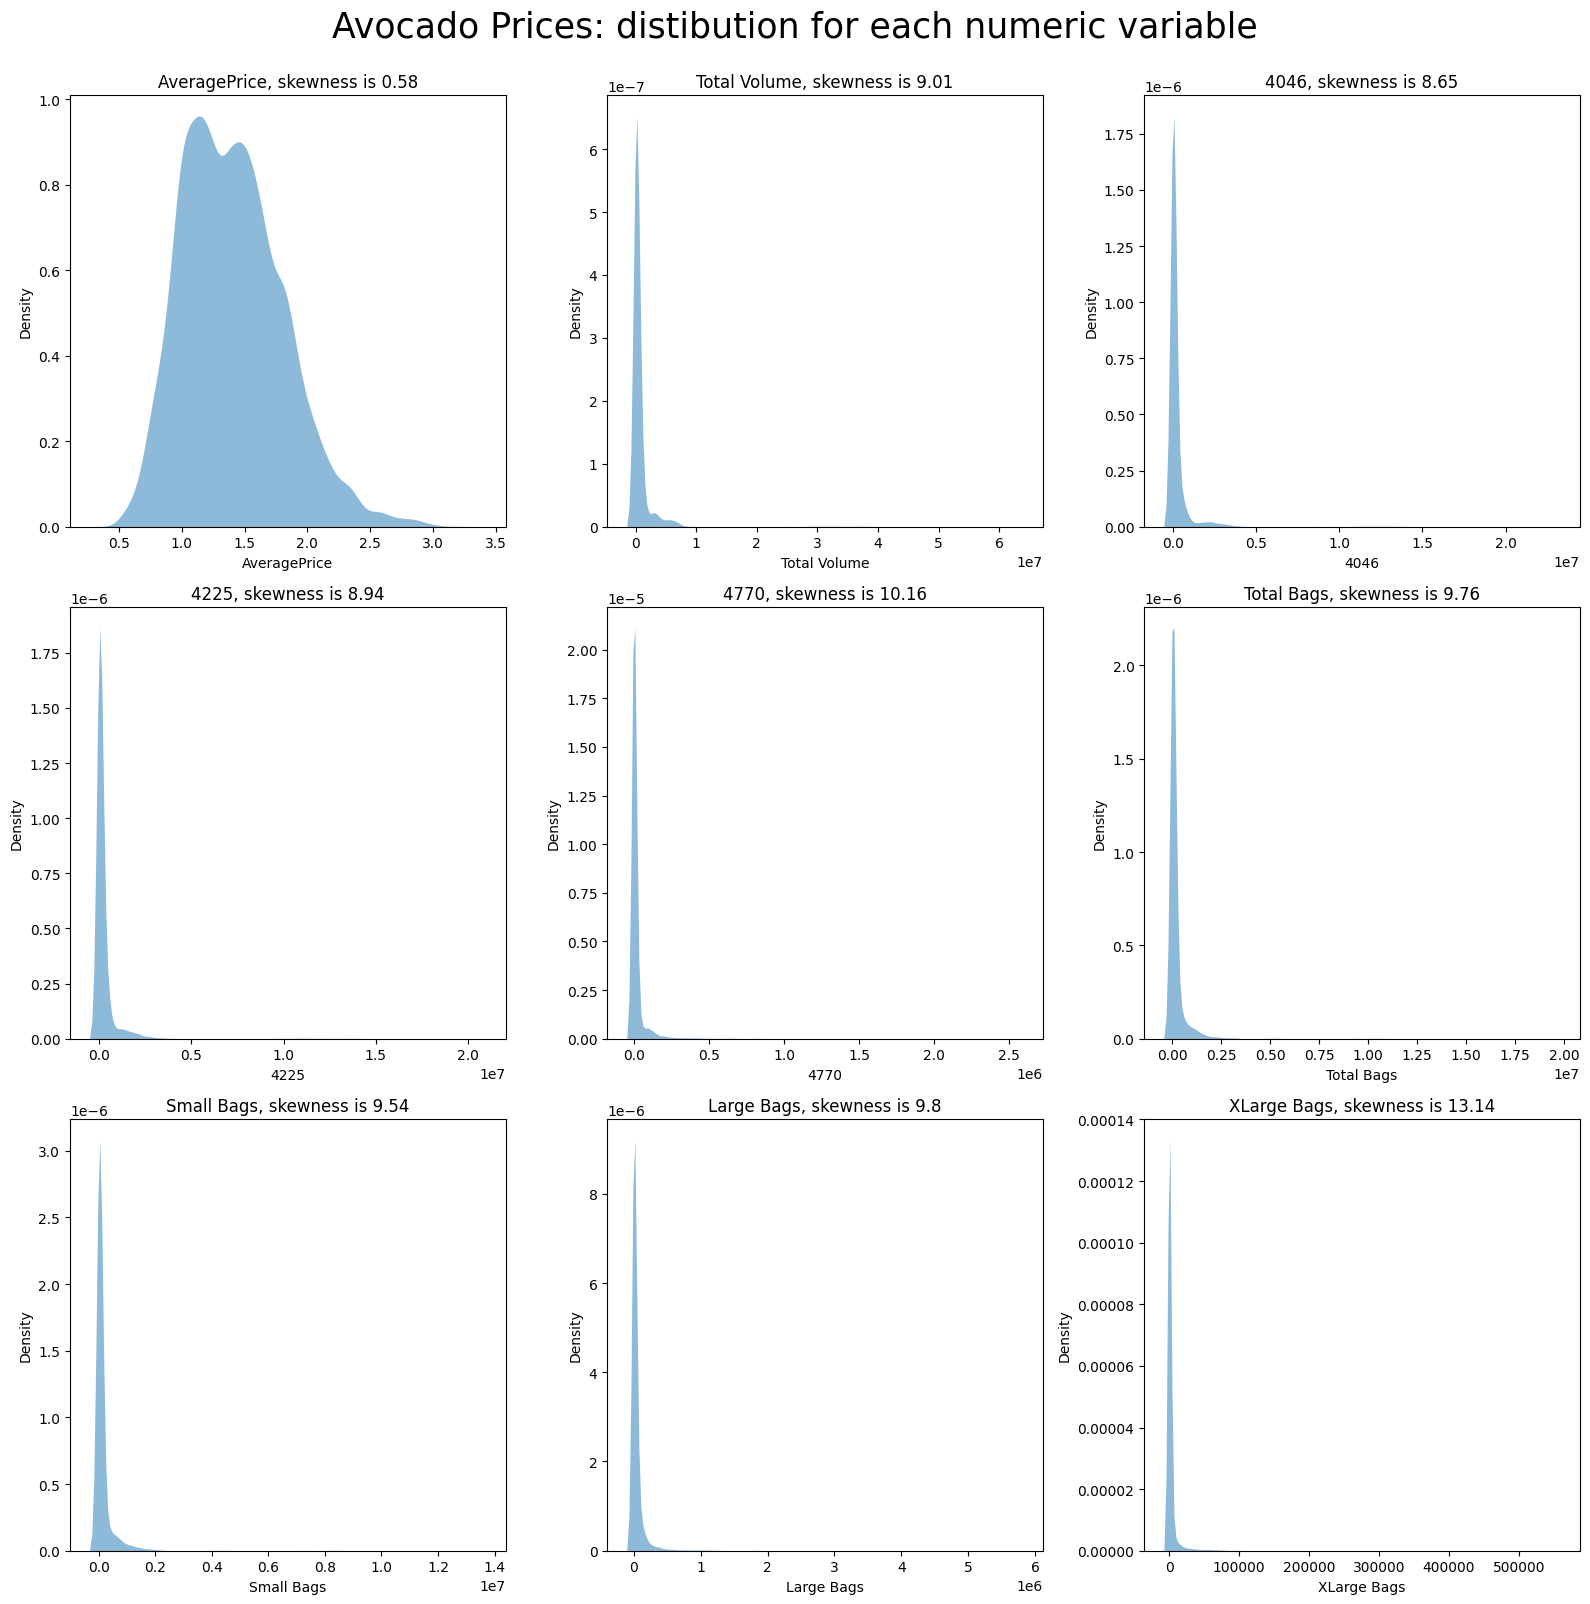

In [ ]:
def dist_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols,figsize=(16,16))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.kdeplot(dataset[data], ax=axs[i], fill=True,  alpha=.5, linewidth=0)
        axs[i].set_title(data + ', skewness is '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))

dist_custom(dataset=raw_df1, columns_list=numeric_columns, rows=3, cols=3, suptitle='Avocado Prices: distibution for each numeric variable')
plt.tight_layout()

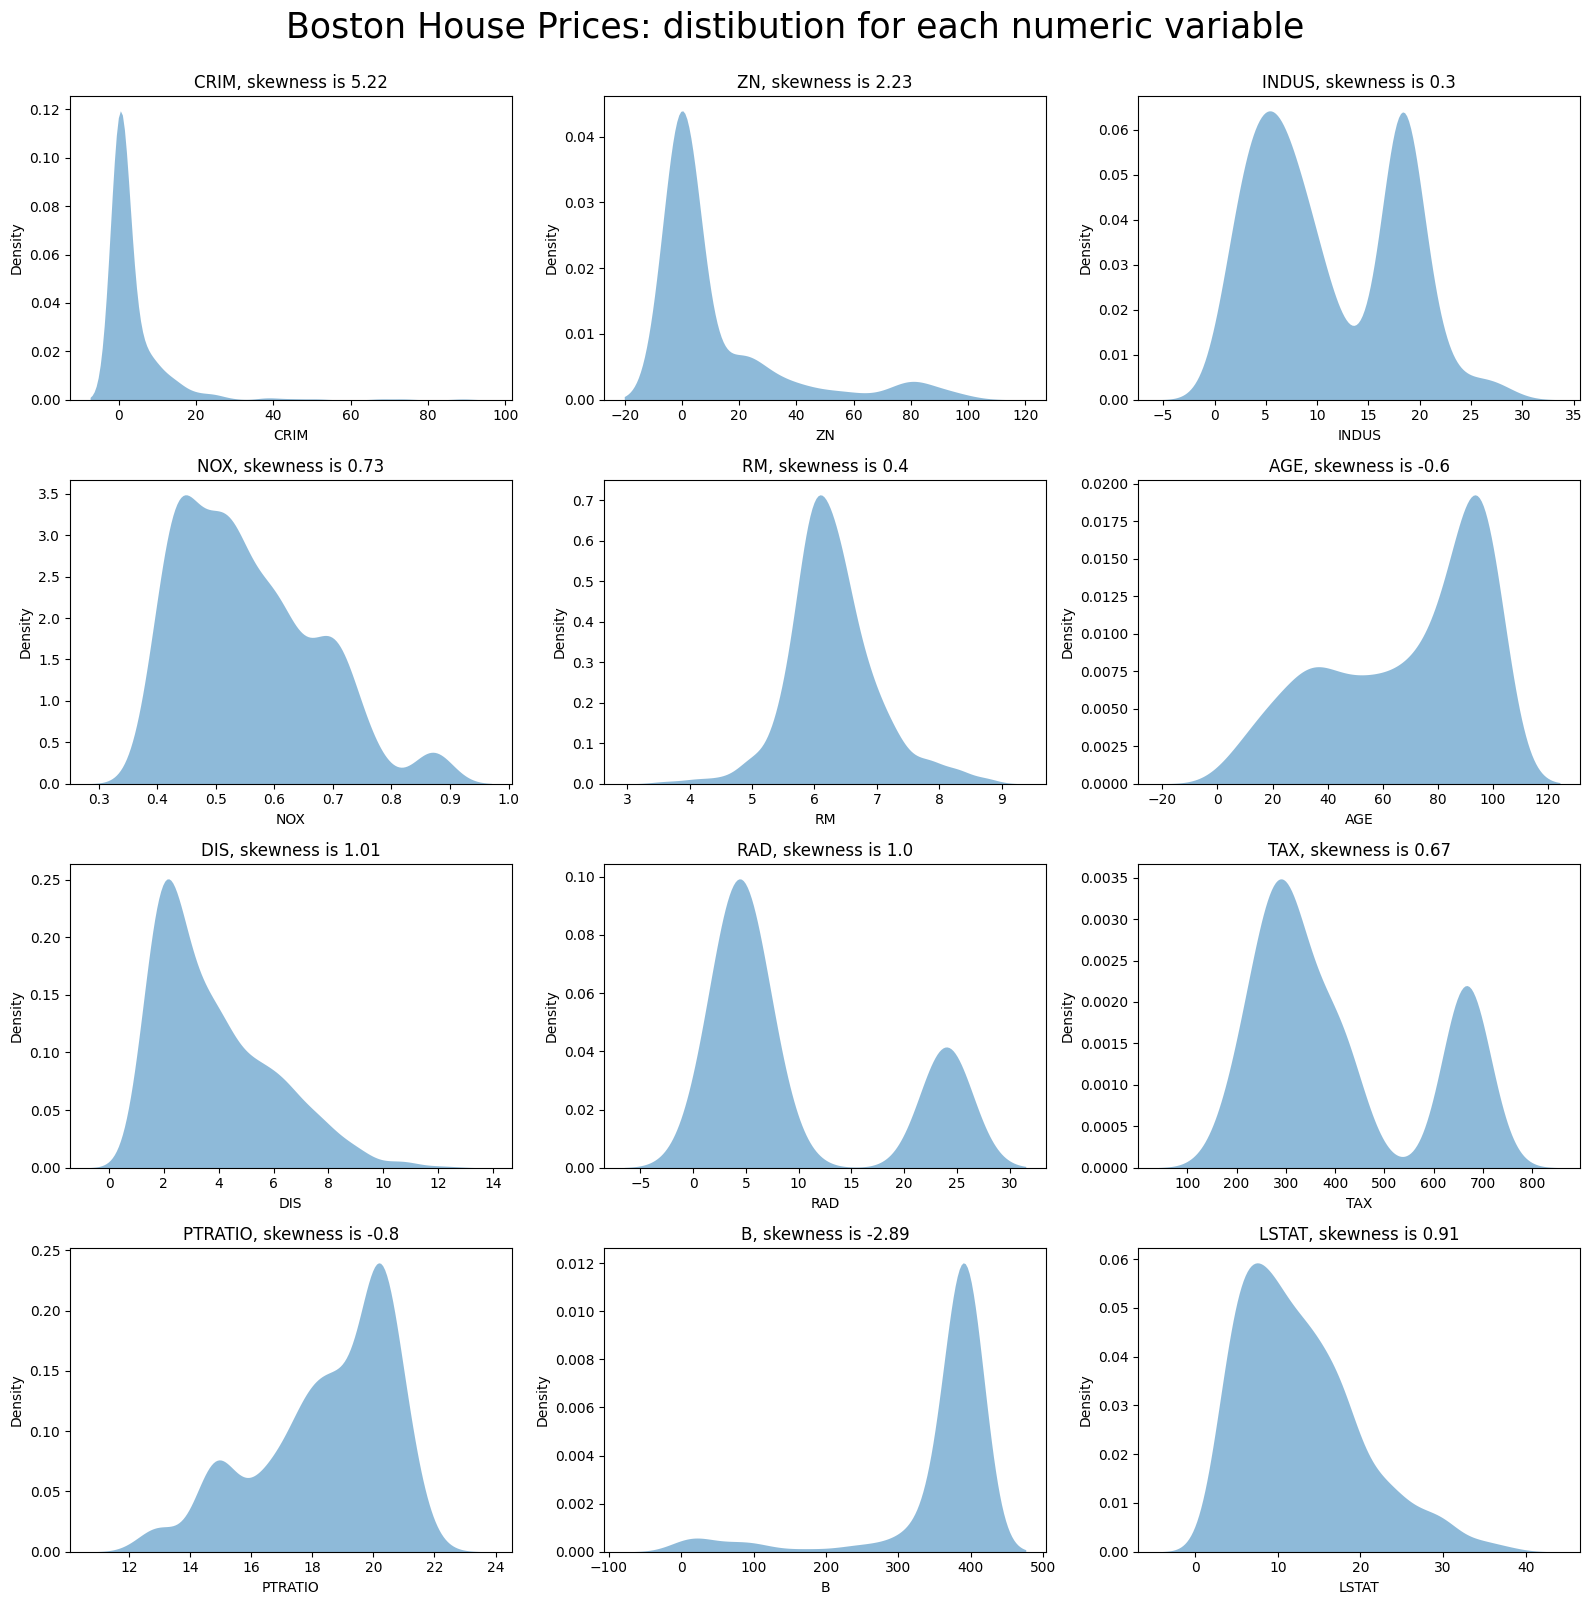

In [ ]:
dist_custom(dataset=raw_df2, columns_list=numeric_columns_boston, rows=4, cols=3, suptitle='Boston House Prices: distibution for each numeric variable')
plt.tight_layout()

In [ ]:
for i in raw_df1.columns:
    if i == 'Date':
        raw_df1[i] = raw_df1[i].astype('datetime64[ns]')
    elif raw_df1[i].dtype == 'object':
        raw_df1[i] = raw_df1[i].astype('category')


In [ ]:
df1 = raw_df1.copy()

df1['Date'] = pd.to_datetime(df1['Date'])
df1['month'] = df1['Date'].dt.month

df1['Spring'] = df1['month'].between(3,5,inclusive='both')
df1['Summer'] = df1['month'].between(6,8,inclusive='both')
df1['Fall'] = df1['month'].between(9,11,inclusive='both')
# df1['Winter'] = df1['month'].between(12,2,inclusive='both')

df1.Spring = df1.Spring.replace({True: 1, False: 0})
df1.Summer = df1.Summer.replace({True: 1, False: 0})
df1.Fall = df1.Fall.replace({True: 1, False: 0})

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1['type'] = le.fit_transform(df1['type'])

# Encoding 'region' (One Hot Encoding)
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
ohe = pd.get_dummies(data=df1, columns=['region'])

df1 = ohe.drop(['Date','4046','4225','4770','Small Bags','Large Bags','XLarge Bags'], axis=1)

In [ ]:
def IQR_method (df,n,features):
    """
    Takes a dataframe and returns an index list corresponding to the observations
    containing more than n outliers according to the Tukey IQR method.
    """
    outlier_list = []

    for column in features:

        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column],75)

        # Interquartile range (IQR)
        IQR = Q3 - Q1

        # outlier step
        outlier_step = 1.5 * IQR

        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index

        # appending the list of outliers
        outlier_list.extend(outlier_list_column)

    # selecting observations containing more than x outliers
    outlier_list = Counter(outlier_list)
    multiple_outliers = list( k for k, v in outlier_list.items() if v > n )

    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df[df[column] < Q1 - outlier_step]
    df2 = df[df[column] > Q3 + outlier_step]

    print('Total number of deleted outliers:', df1.shape[0]+df2.shape[0])

    return multiple_outliers


In [ ]:
numeric_columns2 = ['Total Volume', 'Total Bags']

Outliers_IQR = IQR_method(df1,1,numeric_columns2)
# dropping outliers
df1 = df1.drop(Outliers_IQR, axis = 0).reset_index(drop=True)

Total number of deleted outliers: 2533


In [ ]:
numeric_columns2 = ['CRIM', 'ZN', 'NOX', 'RM', 'AGE', 'DIS', 'PTRATIO', 'B', 'LSTAT']

Outliers_IQR = IQR_method(raw_df2,1,numeric_columns2)
# dropping outliers
df2 = raw_df2.drop(Outliers_IQR, axis = 0).reset_index(drop=True)

Total number of deleted outliers: 7


In [ ]:
X = df1.drop('AveragePrice', axis=1)
y = df1['AveragePrice']

X2 = raw_df2.iloc[:, :-1]
y2 = raw_df2.iloc[:, -1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Creating function for scaling
def Standard_Scaler (df, col_names):
    features = df[col_names]
    scaler = StandardScaler().fit(features.values)
    features = scaler.transform(features.values)
    df[col_names] = features

    return df

In [ ]:
col_names = ['Total Volume', 'Total Bags']
X_train = Standard_Scaler (X_train, col_names)
X_test = Standard_Scaler (X_test, col_names)

col_names = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_train2 = Standard_Scaler (X_train2, col_names)
X_test2 = Standard_Scaler (X_test2, col_names)

In [ ]:
from sklearn.linear_model import LinearRegression

# Creating and training model
lm = LinearRegression()
lm.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = lm.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(lm,X_train,y_train,X_test,y_test,y_pred)]

lm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lm_score.insert(0, 'Model', 'Linear Regression')
lm_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.598793,0.593598,0.604279,0.255931


Text(0.5, 1.0, 'Linear regression for Avocado dataset')

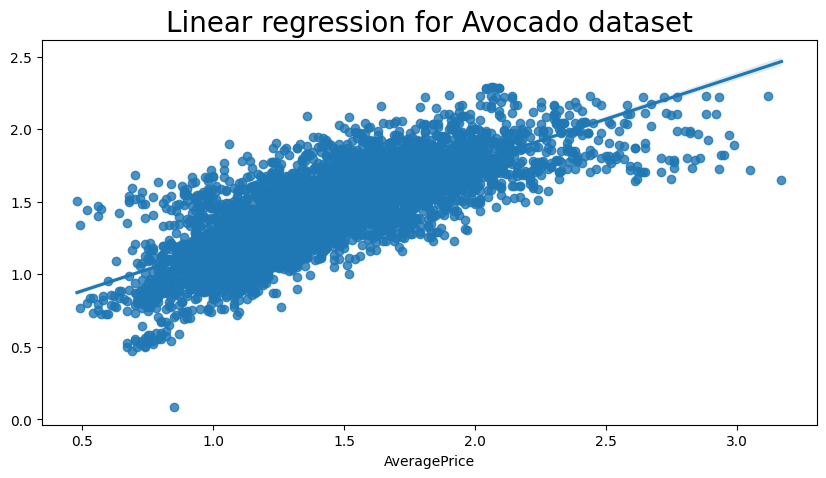

In [ ]:
plt.figure(figsize = (10,5))
sns.regplot(x=y_test,y=y_pred)
plt.title('Linear regression for Avocado dataset', fontsize = 20)

In [ ]:
lm.fit(X_train2, y_train2)
y_pred = lm.predict(X_test2)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(lm,X_train2,y_train2,X_test2,y_test2,y_pred)]

lm_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lm_score2.insert(0, 'Model', 'Linear Regression')
lm_score2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.679168,0.648945,0.687535,4.889394


## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training model
RandomForest_reg = RandomForestRegressor(n_estimators = 10, random_state = 0)

In [ ]:
RandomForest_reg.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = RandomForest_reg.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(RandomForest_reg,X_train,y_train,X_test,y_test,y_pred)]

rf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score.insert(0, 'Model', 'Random Forest')
rf_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest,0.78712,0.784363,0.876525,0.186426


In [ ]:
RandomForest_reg.fit(X_train2, y_train2)
# Model making a prediction on test data
y_pred = RandomForest_reg.predict(X_test2)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(RandomForest_reg,X_train2,y_train2,X_test2,y_test2,y_pred)]

rf_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score2.insert(0, 'Model', 'Random Forest')
rf_score2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest,0.838576,0.823369,0.817514,3.468169


In [ ]:
from sklearn.linear_model import Ridge

# Creating and training model
ridge_reg = Ridge(alpha=3, solver="cholesky")

In [ ]:
ridge_reg.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = ridge_reg.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(ridge_reg,X_train,y_train,X_test,y_test,y_pred)]

rr_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rr_score.insert(0, 'Model', 'Ridge Regression')
rr_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Ridge Regression,0.598733,0.593537,0.604317,0.25595


In [ ]:
ridge_reg.fit(X_train2, y_train2)
# Model making a prediction on test data
y_pred = ridge_reg.predict(X_test2)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(ridge_reg,X_train2,y_train2,X_test2,y_test2,y_pred)]

rr_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rr_score2.insert(0, 'Model', 'Ridge Regression')
rr_score2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Ridge Regression,0.678696,0.648428,0.689293,4.892991


In [ ]:
from xgboost import XGBRegressor
# create an xgboost regression model
XGBR = XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.8, colsample_bytree=0.8)


In [ ]:
XGBR.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = XGBR.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(XGBR,X_train,y_train,X_test,y_test,y_pred)]

XGBR_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
XGBR_score.insert(0, 'Model', 'XGBoost')
XGBR_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,XGBoost,0.786301,0.783534,0.914472,0.186784


In [ ]:
XGBR.fit(X_train2, y_train2)
# Model making a prediction on test data
y_pred = XGBR.predict(X_test2)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(XGBR,X_train2,y_train2,X_test2,y_test2,y_pred)]

XGBR_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
XGBR_score2.insert(0, 'Model', 'XGBoost')
XGBR_score2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,XGBoost,0.875743,0.864038,0.842001,3.042817


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

# create pipeline
rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=60)
model = RandomForestRegressor()
rf_pipeline = Pipeline(steps=[('s',rfe),('m',model)])

In [ ]:
rf_pipeline.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = rf_pipeline.predict(X_test)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(rf_pipeline,X_train,y_train,X_test,y_test,y_pred)]

rfe_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rfe_score.insert(0, 'Model', 'Random Forest with RFE')
rfe_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.79911,0.796508,0.888291,0.1811


In [ ]:
rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=8)
model = RandomForestRegressor()
rf_pipeline = Pipeline(steps=[('s',rfe),('m',model)])

rf_pipeline.fit(X_train2, y_train2)
# Model making a prediction on test data
y_pred = rf_pipeline.predict(X_test2)

In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(rf_pipeline,X_train2,y_train2,X_test2,y_test2,y_pred)]

rfe_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rfe_score2.insert(0, 'Model', 'Random Forest with RFE')
rfe_score2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.853447,0.839641,0.818763,3.304564


In [ ]:
predictions = pd.concat([rfe_score, XGBR_score, rr_score, rf_score, lm_score], ignore_index=True, sort=False)
predictions

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.799110,0.796508,0.888291,0.181100
1,XGBoost,0.786301,0.783534,0.914472,0.186784
2,Ridge Regression,0.598733,0.593537,0.604317,0.255950
3,Random Forest,0.787120,0.784363,0.876525,0.186426
4,Linear Regression,0.598793,0.593598,0.604279,0.255931


In [ ]:
predictions2 = pd.concat([rfe_score2, XGBR_score2, rr_score2, rf_score2, lm_score2], ignore_index=True, sort=False)
predictions2

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Random Forest with RFE,0.853447,0.839641,0.818763,3.304564
1,XGBoost,0.875743,0.864038,0.842001,3.042817
2,Ridge Regression,0.678696,0.648428,0.689293,4.892991
3,Random Forest,0.838576,0.823369,0.817514,3.468169
4,Linear Regression,0.679168,0.648945,0.687535,4.889394


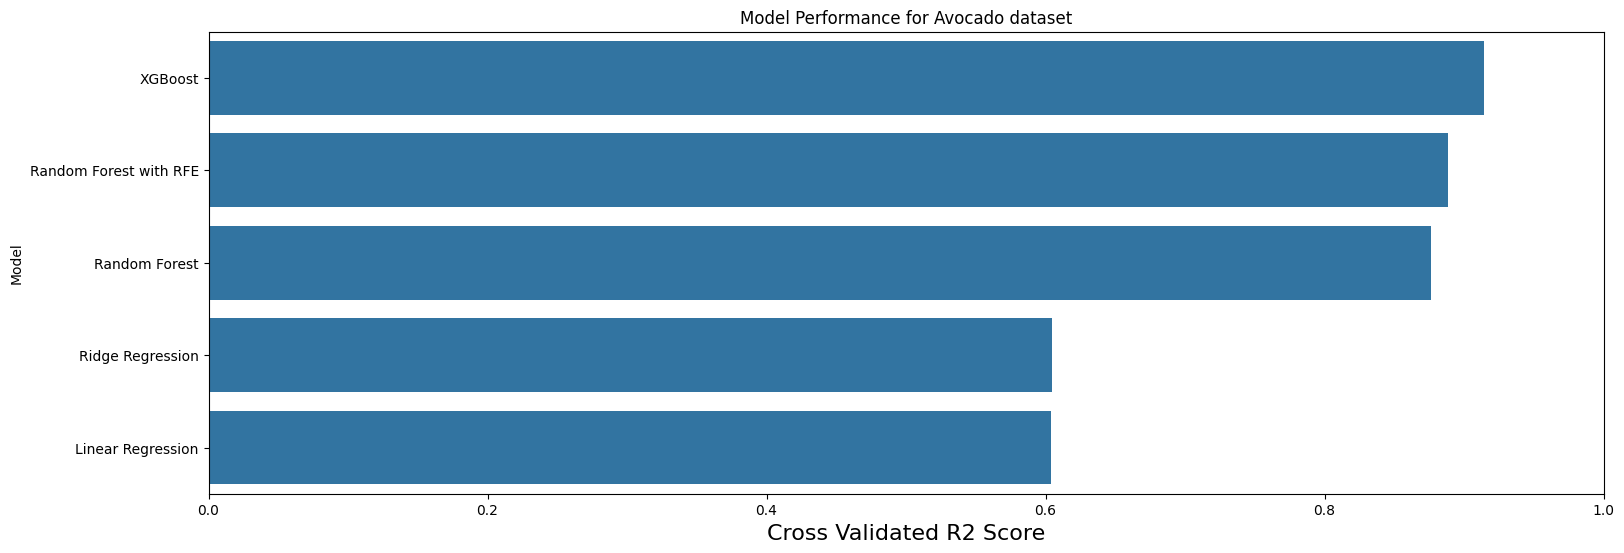

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

predictions.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = predictions, ax = axe)
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)

axe.set(title='Model Performance for Avocado dataset')

plt.show()

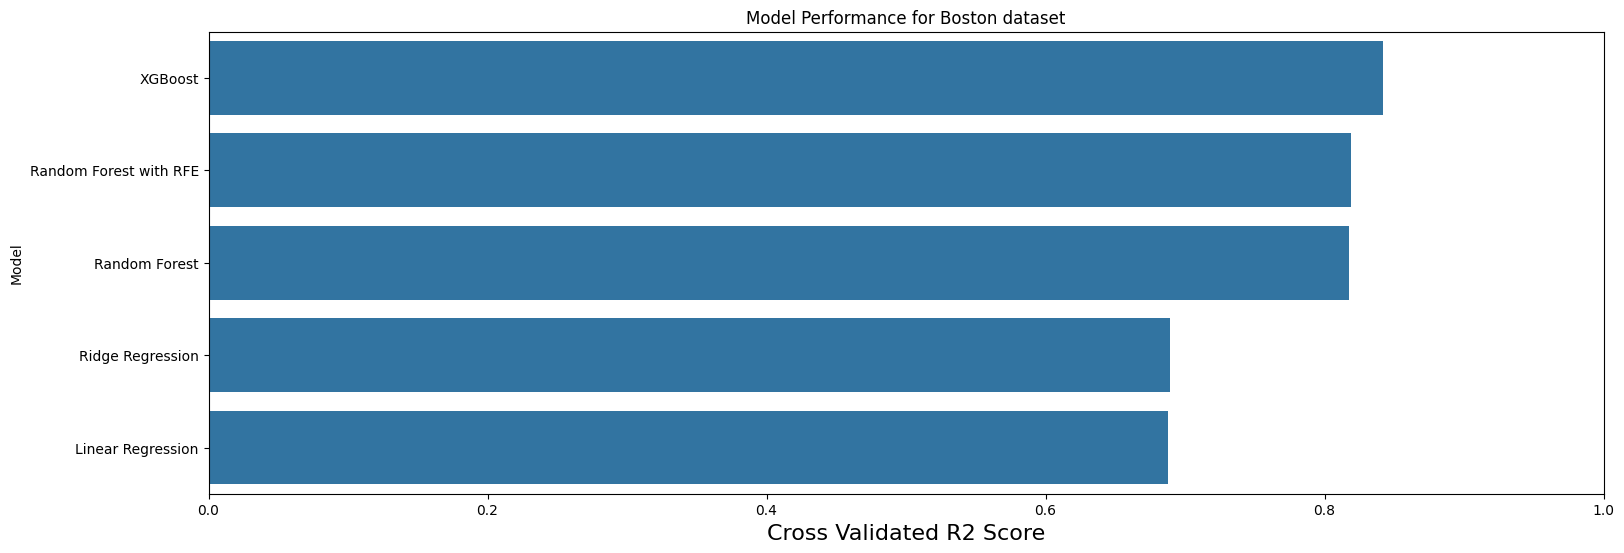

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

predictions2.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = predictions2, ax = axe)
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)

axe.set(title='Model Performance for Boston dataset')
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Polynomial features are those features created by raising existing features to an exponent.
# For example, if a dataset had one input feature X,
# then a polynomial feature would be the addition of a new feature (column) where values were calculated by squaring the values in X, e.g. X^2.

steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge(alpha=3.8, fit_intercept=True))
]

ridge_pipe = Pipeline(steps)
ridge_pipe.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test)

In [ ]:
from sklearn.model_selection import GridSearchCV

alpha_params = [{'model__alpha': list(range(1, 15))}]

clf = GridSearchCV(ridge_pipe, alpha_params, cv = 10)

In [ ]:
# Fit and tune model
clf.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test)
# The combination of hyperparameters along with values that give the best performance of our estimate specified
print(clf.best_params_)

{'model__alpha': 1}


In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(clf,X_train,y_train,X_test,y_test,y_pred)]

clf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
clf_score.insert(0, 'Model', 'Tuned Ridge Regression')
clf_score

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Tuned Ridge Regression,0.736622,0.733212,0.739008,0.210438


In [ ]:
steps = [
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge(alpha=3.8, fit_intercept=True))
]

ridge_pipe = Pipeline(steps)
ridge_pipe.fit(X_train2, y_train2)

# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test2)

alpha_params = [{'model__alpha': list(range(1, 15))}]

clf = GridSearchCV(ridge_pipe, alpha_params, cv = 10)
# Fit and tune model
clf.fit(X_train2, y_train2)
# Model making a prediction on test data
y_pred = ridge_pipe.predict(X_test2)
# The combination of hyperparameters along with values that give the best performance of our estimate specified
print(clf.best_params_)

{'model__alpha': 12}


In [ ]:
ndf = [Reg_Models_Evaluation_Metrics(clf,X_train2,y_train2,X_test2,y_test2,y_pred)]

clf_score2 = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
clf_score2.insert(0, 'Model', 'Tuned Ridge Regression')
clf_score2

In [ ]:
result = pd.concat([clf_score, predictions], ignore_index=True, sort=False)
result

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

result.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = result, ax = axe)
#axes[0].set(xlabel='Region', ylabel='Charges')
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)
axe.set(title='Model Performance for Avocado dataset')

plt.show()

In [ ]:
result = pd.concat([clf_score2, predictions2], ignore_index=True, sort=False)
result

In [ ]:
f, axe = plt.subplots(1,1, figsize=(18,6))

result.sort_values(by=['Cross Validated R2 Score'], ascending=False, inplace=True)

sns.barplot(x='Cross Validated R2 Score', y='Model', data = result, ax = axe)
#axes[0].set(xlabel='Region', ylabel='Charges')
axe.set_xlabel('Cross Validated R2 Score', size=16)
axe.set_ylabel('Model')
axe.set_xlim(0,1.0)
axe.set(title='Model Performance for Boston dataset')

plt.show()
